# Downstream Analysis

This tutorial builds on the quickstarts ({doc}`single <zero_shot_quickstart>` / {doc}`multi-sample <zero_shot_quickstart_multisample>`) and shows the analyses TERRA embeddings unlock: **gene-level embeddings**, **spatial gene-pair scoring**, **spatial structure (Earth Mover's Distance)**, **subsetting**, and **in-silico perturbation**. We run them on the two Human Breast Cancer sections from the multi-sample quickstart.

:::{note}
**TERRA requires an NVIDIA GPU** for the embedding step.
:::

## 1. Setup, data, and embeddings

We download the two breast cancer sections (as in the {doc}`multi-sample quickstart <zero_shot_quickstart_multisample>`) and embed both at once, this time also saving the tokenized dataset to disk — the downstream functions operate on that tokenized `dataset`.

In [1]:
import logging

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
import torch
from datasets import load_from_disk

from terra import (download_pretrained, embed_dataset, get_average_gene_embed,
                   get_emd_distance, get_gene_embed, get_spatial_score,
                   harmonize_tokenize_embed_pipeline, perturb_dataset)
from terra.datasets import read_xenium_10x
from terra.utils.evaluation import get_top_gene_pairs, get_top_gene_score

logging.basicConfig(level="INFO")
sc.settings.set_figure_params(dpi=80, frameon=False)

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
# Two sections of the 10x Xenium Human Breast Cancer panel (313 genes). The
# reader downloads the small standalone files on first run and caches them.
def load_sample(base_url, out_dir, sample):
    adata = read_xenium_10x(base_url, out_dir)
    # Namespace cell ids by sample so they stay unique after concatenation.
    adata.obs["sample"] = sample
    adata.obs_names = sample + "_" + adata.obs_names.astype(str)
    adata.obs["cell_id"] = adata.obs_names.astype(str)
    # Crop a contiguous window per section, centred on the median cell
    # position (the bounding-box corner is often empty), to keep things fast.
    xy = adata.obsm["spatial"]
    center = np.median(xy, axis=0)
    keep = (np.abs(xy - center) <= 375).all(axis=1)
    return adata[keep].copy()


base = "https://cf.10xgenomics.com/samples/xenium/1.0.1"
rep1 = load_sample(f"{base}/Xenium_FFPE_Human_Breast_Cancer_Rep1/Xenium_FFPE_Human_Breast_Cancer_Rep1",
                   "data/breast_rep1", "rep1")
rep2 = load_sample(f"{base}/Xenium_FFPE_Human_Breast_Cancer_Rep2/Xenium_FFPE_Human_Breast_Cancer_Rep2",
                   "data/breast_rep2", "rep2")

adata = ad.concat([rep1, rep2])
print(adata.obs["sample"].value_counts())
print(adata)

sample
rep2    3307
rep1    2213
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 5520 × 313
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample', 'cell_id'
    obsm: 'spatial'


In [3]:
# By default the model is cached in the Hugging Face cache; pass
# local_dir="terra_model" to download it into a folder of your choice.
model_dir = download_pretrained("Lotfollahi-lab/TERRA-112M")

# Batch size for every model-inference step below (the pipeline and the
# downstream functions). Lower it if you run out of GPU memory.
batch_size = 128

adata = harmonize_tokenize_embed_pipeline(
    adata=adata,
    sample_key="sample",      # tokenize each section separately
    batch_key="sample",
    model_folder_path=model_dir,
    cache_directory_path="./terra_cache",
    save_dataset_path="./terra_cache/breast.dataset",
    batch_size=batch_size,
    add_neigh_cell_ids=True,  # store neighbor IDs, needed for the
                              # neighborhood-of-selected-cells perturbation below
)

# The tokenized dataset that the downstream functions consume.
dataset = load_from_disk("./terra_cache/breast.dataset")

# Ensembl IDs of the panel genes (added to adata.var by harmonization).
gene_ids = list(adata.var["ensembl_id"])

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/Lotfollahi-lab/TERRA-112M/revision/main "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/lotfollahi-lab/TERRA-112M/revision/main "HTTP/1.1 200 OK"


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

INFO:terra.inference.embed:Harmonizing AnnData...
INFO:terra.inference.harmonize:STEP 1: DATA VALIDATION...
INFO:terra.inference.harmonize:Checking that adata.X contains raw counts...
INFO:terra.inference.harmonize:✓ adata.X contains raw counts (integer values).
INFO:terra.inference.harmonize:STEP 2: ADDING ENSEMBL IDS...
INFO:terra.inference.harmonize:Adding ensembl IDs from gene_mapping_dict with file path `/nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/ensembl_dictionary.pkl`...
INFO:terra.inference.harmonize:Number of genes with matching ensembl IDs: 305.
INFO:terra.inference.harmonize:Filtering genes that have not occurred enough during pretraining...
INFO:terra.inference.harmonize:STEP 3: BASIC QUALITY CONTROL...
INFO:terra.inference.harmonize:Filtering cells with less than 0 genes.
INFO:terra.inference.harmonize:Before cell filtering: 5520 cells.
INFO:terra.inference.harmonize:After cell filterin

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/harmonize.py:136: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  adata.var.index = adata_gene_names


...

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
44it [01:27,  1.98s/it]

INFO:terra.inference.embed:Embedded tokenized data.


Loading dataset from disk:   0%|          | 0/32 [00:00<?, ?it/s]

## 2. Gene programs

`get_average_gene_embed` returns, for each gene, its mean embedding across the dataset in two spaces: the **intrinsic** cell-level embedding (driven by a gene's own expression) and the **spatial** neighborhood-level embedding (driven by its tissue context). Clustering genes by these embeddings groups co-varying genes into **gene programs** — clustering the intrinsic embeddings yields **intrinsic gene programs**, while clustering the spatial embeddings yields **spatial gene programs**.

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GETTING AVERAGE GENE EMBEDDINGS
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.
INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:853: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
44it [00:57,  1.31s/it]


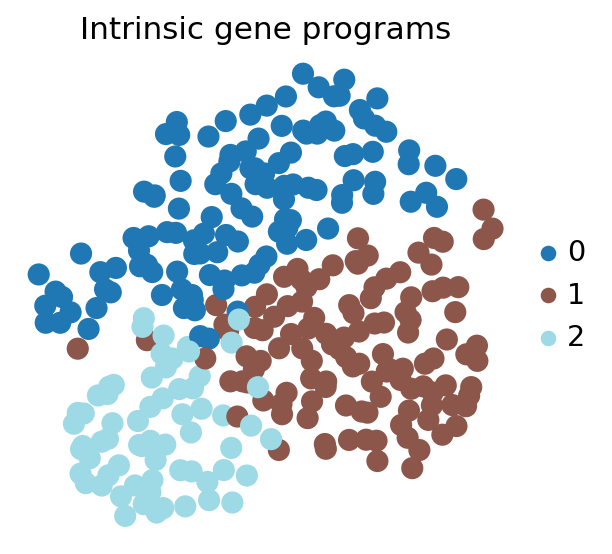

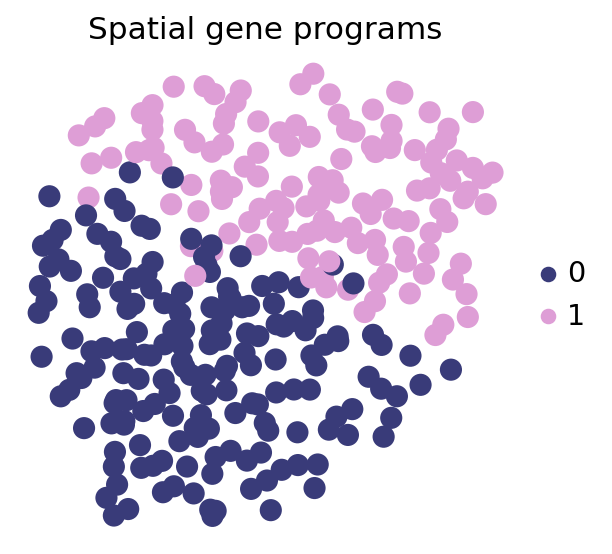

In [4]:
avg = get_average_gene_embed(
    dataset=dataset,
    model_folder_path=model_dir,
    cell_gene_ensembl_id=gene_ids,
    neighborhood_gene_ensembl_id=gene_ids,
    batch_size=batch_size,
)

# Cluster genes by each embedding to recover gene programs: the intrinsic
# (cell-level) embedding gives intrinsic programs, the spatial
# (neighborhood-level) embedding gives spatial programs.
programs = {
    "Intrinsic": avg["cell_gene_emb_average_per_data"],
    "Spatial": avg["neighborhood_gene_emb_average_per_data"],
}
palettes = {"Intrinsic": "tab20", "Spatial": "tab20b"}  # distinct per view
for kind, gene_emb in programs.items():
    gene_emb = np.asarray(gene_emb)
    ok = ~np.isnan(gene_emb).any(axis=1)
    genes = sc.AnnData(gene_emb[ok])
    genes.obs_names = np.asarray(gene_ids, dtype=str)[ok]

    sc.pp.neighbors(genes, use_rep="X", n_neighbors=15)
    sc.tl.umap(genes)
    sc.tl.leiden(genes, resolution=0.5, flavor="igraph", n_iterations=2,
                 directed=False, key_added="program")
    sc.pl.umap(genes, color="program", palette=palettes[kind],
               title=f"{kind} gene programs")

## 3. Cell-level gene embeddings

`get_gene_embed` returns a per-cell embedding for specific genes, in both the intrinsic (cell-level) and spatial (neighborhood-level) spaces. Replace the example Ensembl IDs with genes of interest from your panel. We store the embeddings in `adata.obsm`, then map one gene's embedding across the tissue.

:::{note}
The released models use Ensembl release 111 — look gene symbols up against that release for correct IDs.
:::

In [5]:
genes_of_interest = gene_ids[:2]  # <-- replace with your genes of interest

gene_embed = get_gene_embed(
    dataset=dataset,
    model_folder_path=model_dir,
    cell_gene_ensembl_id=genes_of_interest,
    neighborhood_gene_ensembl_id=genes_of_interest,
    batch_size=batch_size,
)
for key, values in gene_embed.items():
    adata.obsm[key] = values
print(list(gene_embed))

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GETTING GENE EMBEDDINGS
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.
INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
        

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:853: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
44it [00:53,  1.21s/it]

['cell_emb_geneENSG00000165272', 'cell_emb_geneENSG00000124939', 'neighborhood_emb_geneENSG00000165272', 'neighborhood_emb_geneENSG00000124939']


/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'sample' as categorical


/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'sample' as categorical


/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'sample' as categorical


/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'sample' as categorical


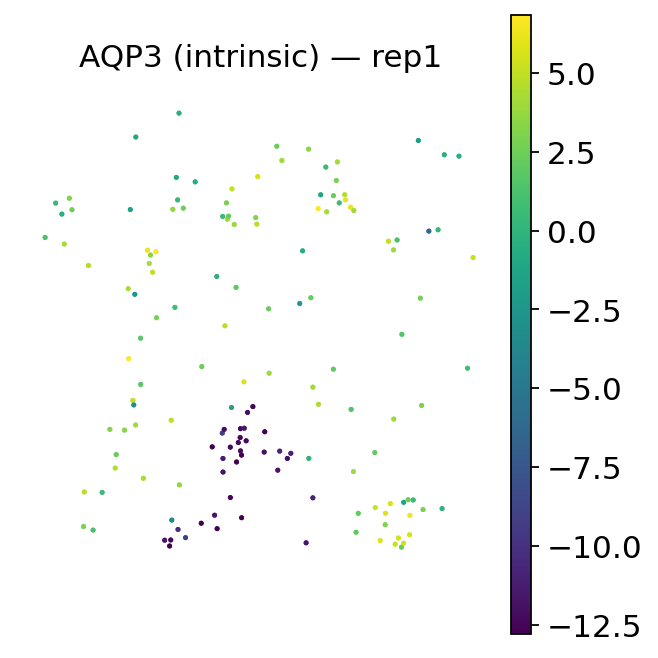

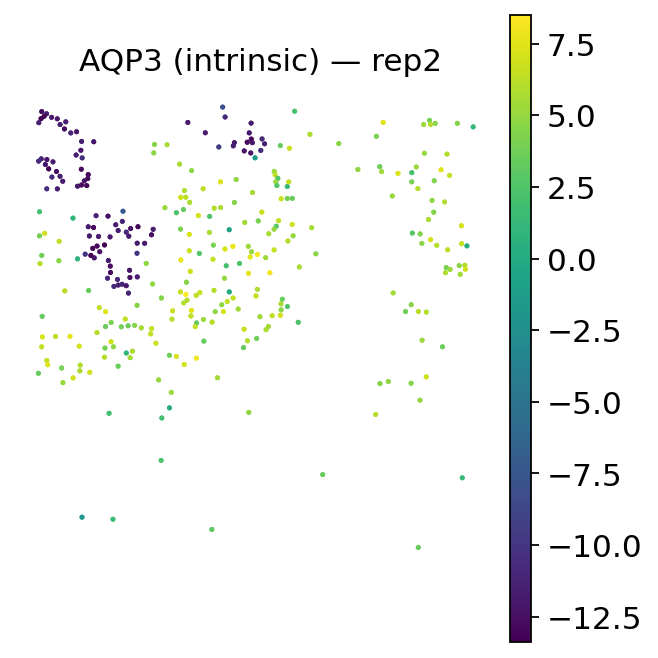

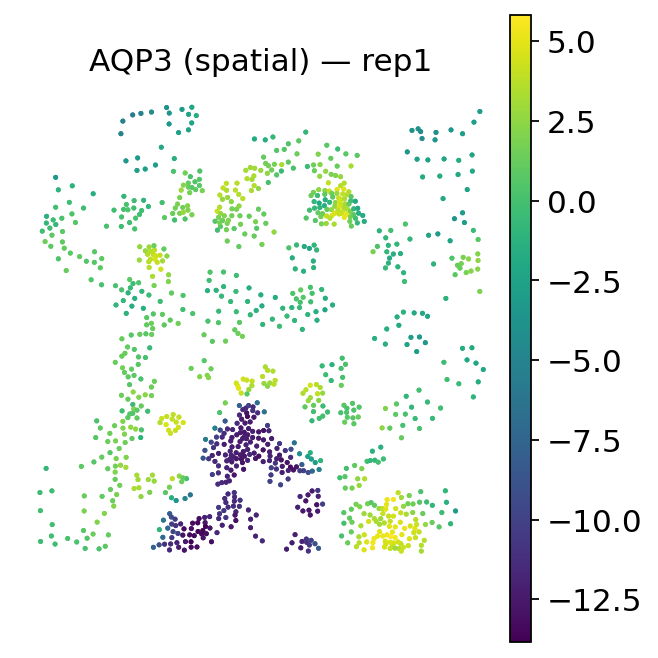

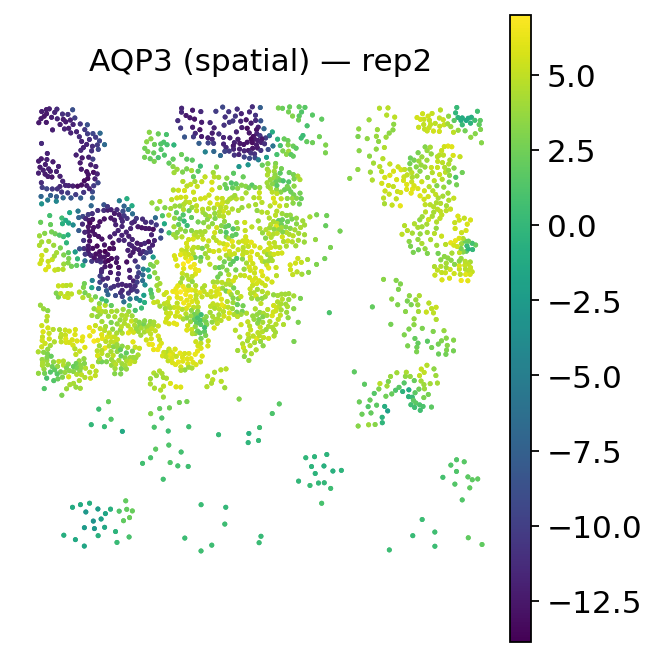

In [6]:
# Map one gene's per-cell embedding across the tissue. Cells that don't express
# the gene are zeroed out by `get_gene_embed`, so we mask them and summarize the
# embedding of the expressing cells with its first principal component (a 1D
# score of how the model contextualizes the gene).
goi = genes_of_interest[0]
match = adata.var_names[adata.var["ensembl_id"] == goi]
symbol = match[0] if len(match) else goi

views = {
    "intrinsic": adata.obsm[f"cell_emb_gene{goi}"],
    "spatial": adata.obsm[f"neighborhood_emb_gene{goi}"],
}
for view, emb in views.items():
    expressed = np.abs(emb).sum(axis=1) > 0          # zeroed rows = gene absent
    score = np.full(adata.n_obs, np.nan)
    if expressed.sum() > 1:
        X = emb[expressed] - emb[expressed].mean(axis=0)
        pc1 = np.linalg.svd(X, full_matrices=False)[2][0]
        score[expressed] = X @ pc1
    col = f"{symbol} ({view})"
    adata.obs[col] = score
    for sample in adata.obs["sample"].unique():
        sq.pl.spatial_scatter(adata[adata.obs["sample"] == sample],
                              color=col, shape=None, size=6,
                              title=f"{col} — {sample}")

## 4. Spatial gene-pair score

`get_spatial_score` compares each gene's cell vs. neighborhood representation; the ratio highlights genes whose signal is spatially structured. `get_top_gene_score` / `get_top_gene_pairs` rank the strongest genes and gene pairs.

In [7]:
score = get_spatial_score(
    dataset=dataset,
    model_folder_path=model_dir,
    cell_gene_ensembl_id=gene_ids,
    neighborhood_gene_ensembl_id=gene_ids,
    batch_size=batch_size,
)
gene_pair_score = score["cos_sim_neighborhood"] / score["cos_sim_cell"]

df_scores = get_top_gene_score(
    gene_pair_score,
    cell_gene_ensembl_id=gene_ids,
    gene_df=adata.var,
    gene_counts=score["cell_count_neighborhood"],
    min_count=20,
)
df_scores.sort_values("gene_score", ascending=False).head(20)

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: COMPUTE THE COSINE SIMILARITY SCORE BETWEEN GENES IN THE CELL AND GENES IN THE NEIGHBORHOOD.
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.
INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:853: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
44it [00:55,  1.27s/it]
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/score.py:127: RuntimeWarning: invalid value encountered in divide
  out_put_cosine_sim_score[f"cos_sim_{compute_cosine_with}"] = out_put_cosine_sim_score[f"sum_cos_sim_{compute_cosine_with}"] / out_put_cosine_sim_score[f"pair_count_{compute_cosine_with}"]


,gene_ensembl,gene_name,gene_score
99,ENSG00000135480,KRT7,0.890370
59,ENSG00000188112,C6orf132,0.887962
260,ENSG00000096696,DSP,0.885952
65,ENSG00000091986,CCDC80,0.885336
143,ENSG00000135374,ELF5,0.877753
230,ENSG00000010278,CD9,0.876657
275,ENSG00000176692,FOXC2,0.874275
117,ENSG00000171346,KRT15,0.870678
43,ENSG00000133110,POSTN,0.870614
135,ENSG00000172889,EGFL7,0.868983


In [8]:
df_pairs = get_top_gene_pairs(
    torch.from_numpy(gene_pair_score),
    count_cell=torch.from_numpy(score["cell_count_cell"]),
    count_neb=torch.from_numpy(score["cell_count_neighborhood"]),
    cos_sim_cell=torch.from_numpy(score["cos_sim_cell"]),
    cos_sim_neb=torch.from_numpy(score["cos_sim_neighborhood"]),
    gene_df=adata.var,
    cell_gene_ids=gene_ids,
    neighborhood_gene_ids=gene_ids,
    min_count=20,
    k=100,
)
df_pairs.head(20)

,row_idx,col_idx,cell_ensembl,neb_ensembl,cell_gene_name,neb_gene_name,gene_pair_score
0,99,73,ENSG00000171199,ENSG00000139329,OPRPN,LUM,1.109339
1,53,239,ENSG00000188389,ENSG00000081237,PDCD1,PTPRC,1.083771
2,234,275,ENSG00000181092,ENSG00000106483,ADIPOQ,SFRP4,1.043019
3,97,225,ENSG00000196091,ENSG00000157404,MYBPC1,KIT,1.031743
4,224,74,ENSG00000188404,ENSG00000197992,SELL,CLEC9A,1.029950
5,157,153,ENSG00000135374,ENSG00000087245,ELF5,MMP2,1.023376
6,43,277,ENSG00000006128,ENSG00000126353,TAC1,CCR7,1.019493
7,53,23,ENSG00000188389,ENSG00000121966,PDCD1,CXCR4,1.018093
8,97,144,ENSG00000196091,ENSG00000104332,MYBPC1,SFRP1,1.013424
9,234,73,ENSG00000181092,ENSG00000139329,ADIPOQ,LUM,1.013236


## 5. Spatial structure (Earth Mover's Distance)

For each cell, `get_emd_distance` compares the gene–gene relationships in the cell's own (intrinsic) embedding against those in its spatial neighborhood, and summarizes the difference as an **Earth Mover's Distance (EMD)**. A high EMD marks cells whose local tissue context most reshapes their gene relationships — tissue boundaries and structured microenvironments — while a low EMD marks cells coherent with their surroundings. Plotting it in space shows how spatially organized each region is.

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: COMPUTE EMD DISTANCE BETWEEN GENE IN CELL AND NEIGHBORHOOD
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.
INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:853: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
44it [01:19,  1.81s/it]
/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'sample' as categorical


/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
... storing 'sample' as categorical


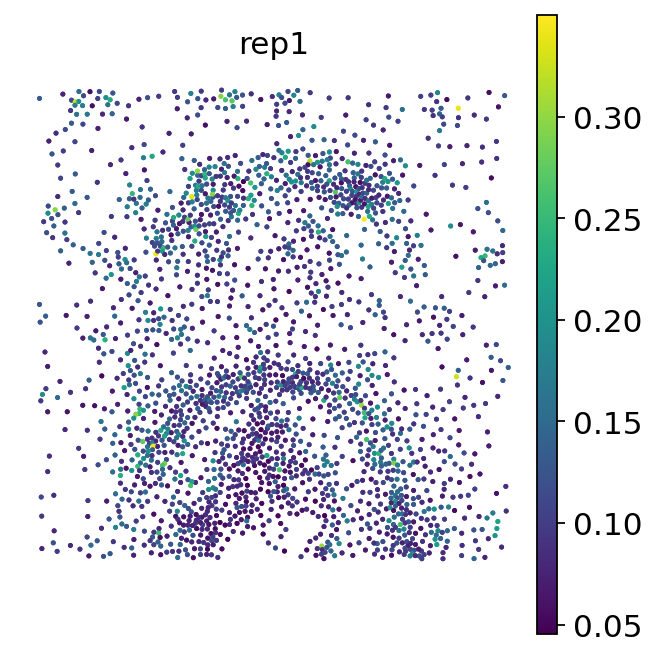

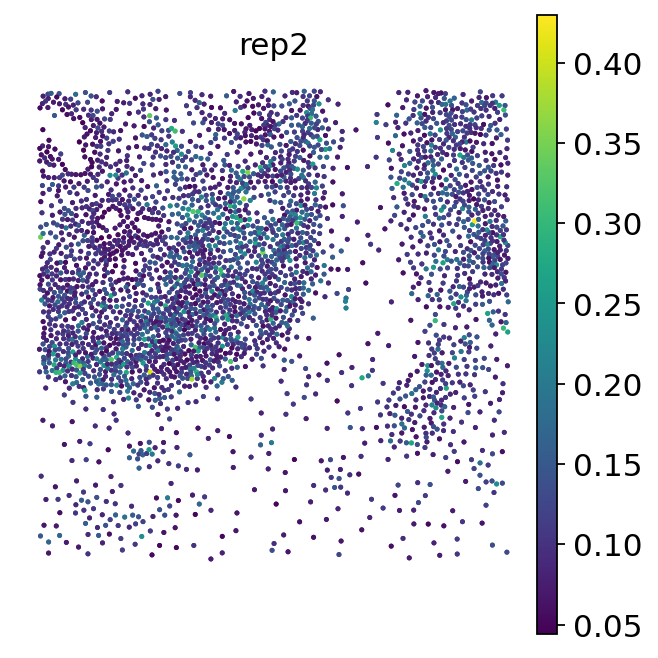

In [9]:
# get_emd_distance returns (per-cell EMD distance, per-cell gene matrix); the
# per-cell distance is what we map in space.
emd_dist, _ = get_emd_distance(
    dataset=dataset,
    model_folder_path=model_dir,
    cell_gene_ensembl_id=gene_ids,
    neighborhood_gene_ensembl_id=gene_ids,
    batch_size=batch_size,
)
adata.obs["emd_dist"] = emd_dist
# Plot each section separately (the two sections share a coordinate frame).
for sample in adata.obs["sample"].unique():
    sq.pl.spatial_scatter(adata[adata.obs["sample"] == sample],
                          color="emd_dist", shape=None, size=6, title=sample)

## 6. Analyze a subset of cells

You can restrict the tokenized dataset to a set of cell IDs (e.g. a niche or cell type from a quickstart) and repeat any analysis on it.

In [10]:
# Restrict the tokenized dataset to a set of cell IDs. Read the cell_id column
# once and build the row indices, then use `select` -- far faster than `filter`,
# which scans and rewrites every (large) token row just to test one field.
subset_ids = set(map(str, adata.obs["cell_id"][:1000]))
keep_idx = [i for i, cid in enumerate(dataset["cell_id"]) if str(cid) in subset_ids]
subset = dataset.select(keep_idx)
print(subset)

Dataset({
    features: ['rel_x_coord', 'rel_y_coord', 'cell_ids', 'cell_id', 'gene_tokens', 'gene_expr', 'n_nonzero_tokens'],
    num_rows: 1000
})


## 7. In-silico perturbation

`perturb_dataset` edits gene tokens, and re-embedding with `embed_dataset` shows the effect in latent space. A perturbation is a `perturb_df` with one row per edit, controlled along four axes:

- **type** — `knockout` zeros a gene, `foldchange` scales it;
- **target** — `cell` (the cell's own expression) or `neighborhood` (its spatial context);
- **genes** — specific Ensembl IDs or `"all"`;
- **cells** — specific cell IDs (matched on each cell's `cell_id`) or `"all"`.

Below we run four representative perturbations and compare how each shifts the embedding.

In [11]:
def perturb_and_embed(perturb_df):
    """Apply a perturbation to the tokenized dataset and return the new cell- and
    neighborhood-level embeddings (the original dataset is left unchanged)."""
    perturbed = perturb_dataset(dataset=dataset, perturb_df=perturb_df,
                                model_folder_path=model_dir, nproc=1)
    return embed_dataset(dataset=perturbed, model_folder_path=model_dir,
                         batch_size=batch_size)


results = {}

In [12]:
# 1) Knock out several genes in a selected subset of cells (e.g. a niche or cell
#    type of interest): a cell-target, specific-gene knockout on specific cells.
#    One row per (cell, gene) pair.
selected = adata.obs["cell_id"][:1000].tolist()
ko_genes = gene_ids[:200]
perturb_df = pd.DataFrame([
    {"perturbed_cell_id": cell, "perturbed_ensembl_id": gene,
     "perturbation_target": "cell", "perturbation_type": "knockout",
     "foldchange": np.nan}
    for cell in selected for gene in ko_genes
])
results["knockout genes (selected cells)"] = perturb_and_embed(perturb_df)

INFO:terra.inference.perturb:Applying perturbations using dataframe:
       perturbed_cell_id perturbed_ensembl_id perturbation_target  \
0              rep1_6019      ENSG00000165272                cell   
1              rep1_6019      ENSG00000124939                cell   
2              rep1_6019      ENSG00000168685                cell   
3              rep1_6019      ENSG00000137502                cell   
4              rep1_6019      ENSG00000145365                cell   
...                  ...                  ...                 ...   
199995        rep1_93694      ENSG00000107562                cell   
199996        rep1_93694      ENSG00000157150                cell   
199997        rep1_93694      ENSG00000164736                cell   
199998        rep1_93694      ENSG00000115165                cell   
199999        rep1_93694      ENSG00000148773                cell   

       perturbation_type  foldchange perturbed_gene_token  
0               knockout         NaN      

Map (num_proc=1):   0%|          | 0/5520 [00:00<?, ? examples/s]

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.
INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
       

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
44it [01:26,  1.98s/it]


In [13]:
# 2) Double several genes in every cell: an all-cell, specific-gene, cell-target
#    fold-change.
perturb_df = pd.DataFrame({
    "perturbed_cell_id": "all",
    "perturbed_ensembl_id": gene_ids[:200],
    "perturbation_target": "cell",
    "perturbation_type": "foldchange",
    "foldchange": 2.0,
})
results["fold-change genes (all cells)"] = perturb_and_embed(perturb_df)

INFO:terra.inference.perturb:Applying perturbations using dataframe:
    perturbed_cell_id perturbed_ensembl_id perturbation_target  \
0                 all      ENSG00000165272                cell   
1                 all      ENSG00000124939                cell   
2                 all      ENSG00000168685                cell   
3                 all      ENSG00000137502                cell   
4                 all      ENSG00000145365                cell   
..                ...                  ...                 ...   
195               all      ENSG00000107562                cell   
196               all      ENSG00000157150                cell   
197               all      ENSG00000164736                cell   
198               all      ENSG00000115165                cell   
199               all      ENSG00000148773                cell   

    perturbation_type  foldchange perturbed_gene_token  
0          foldchange         2.0                11477  
1          foldchange   

Map (num_proc=1):   0%|          | 0/5520 [00:00<?, ? examples/s]

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.
INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
       

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
44it [01:27,  1.98s/it]


In [14]:
# 3) Halve the whole panel in each cell's neighborhood: a neighborhood-target
#    fold-change that perturbs the spatial context rather than the cell itself.
perturb_df = pd.DataFrame([{
    "perturbed_cell_id": "all",
    "perturbed_ensembl_id": "all",
    "perturbation_target": "neighborhood",
    "perturbation_type": "foldchange",
    "foldchange": 0.5,
}])
results["fold-change all (neighborhood)"] = perturb_and_embed(perturb_df)

INFO:terra.inference.perturb:Applying perturbations using dataframe:
  perturbed_cell_id perturbed_ensembl_id perturbation_target  \
0               all                  all        neighborhood   

  perturbation_type  foldchange perturbed_gene_token  
0        foldchange         0.5                  all  


Map (num_proc=1):   0%|          | 0/5520 [00:00<?, ? examples/s]

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.
INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
       

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
44it [01:26,  1.97s/it]


In [15]:
# 4) Perturb the neighborhood *role* of a selected subset of cells: wherever one
#    of these cells appears in another cell's neighborhood, knock out its
#    contribution. Unlike (3), this targets specific cells, so it needs the
#    neighbor IDs stored via add_neigh_cell_ids=True.
selected = adata.obs["cell_id"][:200].tolist()
perturb_df = pd.DataFrame({
    "perturbed_cell_id": selected,
    "perturbed_ensembl_id": "all",
    "perturbation_target": "neighborhood",
    "perturbation_type": "knockout",
    "foldchange": np.nan,
})
results["neighborhood of selected cells"] = perturb_and_embed(perturb_df)

INFO:terra.inference.perturb:Applying perturbations using dataframe:
    perturbed_cell_id perturbed_ensembl_id perturbation_target  \
0           rep1_6019                  all        neighborhood   
1           rep1_6020                  all        neighborhood   
2           rep1_6021                  all        neighborhood   
3           rep1_6022                  all        neighborhood   
4           rep1_6023                  all        neighborhood   
..                ...                  ...                 ...   
195        rep1_90323                  all        neighborhood   
196        rep1_90324                  all        neighborhood   
197        rep1_90325                  all        neighborhood   
198        rep1_90326                  all        neighborhood   
199        rep1_90327                  all        neighborhood   

    perturbation_type  foldchange perturbed_gene_token  
0            knockout         NaN                  all  
1            knockout   

Map (num_proc=1):   0%|          | 0/5520 [00:00<?, ? examples/s]

INFO:terra.inference.embed:STEP 1: LOADING CONFIG...
INFO:terra.inference.embed:STEP 2: GENERATING EMBEDDINGS...
INFO:terra.utils.helper:Protein-init: DISABLED -- using the default learnable nn.Embedding for gene tokens.
INFO:terra.utils.helper:EncoderMultiMaskWrapper(
  (backbone): GeneTransformerCombinedEncoder(
    (token_embed): Embedding(23407, 384, padding_idx=0)
    (seg_embed): Embedding(13, 384, padding_idx=0)
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
       

/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 6, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


INFO:terra.utils.helper:Loaded pretrained target encoder from epoch 1 with msg: <All keys matched successfully>.
INFO:terra.utils.helper:Finished loading checkpoint with read path: /nfs/users/nfs_s/sb75/.cache/huggingface/hub/models--Lotfollahi-lab--TERRA-112M/snapshots/00d1c977e49364ba10c28692abcbd102e115bf91/model_checkpoint.pt.


0it [00:00, ?it/s]/nfs/team361/sb75/.venvs/terra-test/lib/python3.10/site-packages/terra/inference/embed.py:265: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(
44it [01:27,  1.98s/it]


cell_emb
  knockout genes (selected cells)    mean shift 0.640
  fold-change genes (all cells)      mean shift 2.630
  fold-change all (neighborhood)     mean shift 0.000
  neighborhood of selected cells     mean shift 0.000
neighborhood_emb
  knockout genes (selected cells)    mean shift 0.131
  fold-change genes (all cells)      mean shift 0.628
  fold-change all (neighborhood)     mean shift 1.134
  neighborhood of selected cells     mean shift 0.265


... storing 'state' as categorical


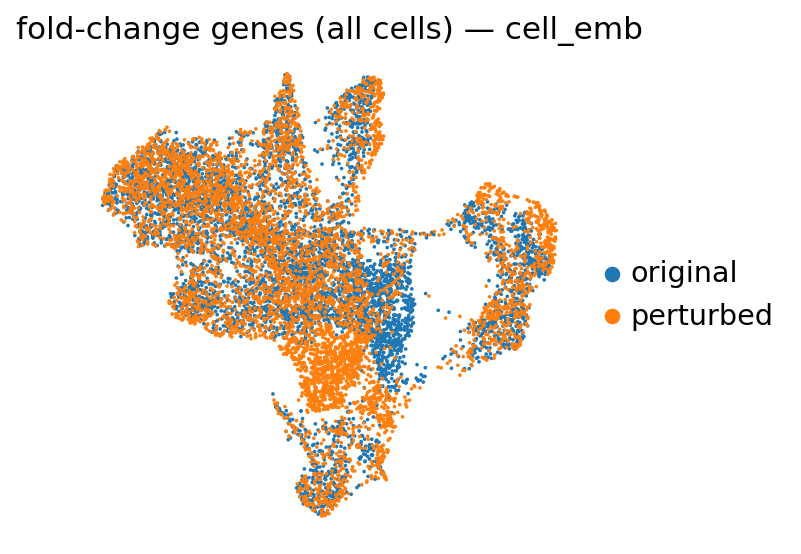

... storing 'state' as categorical


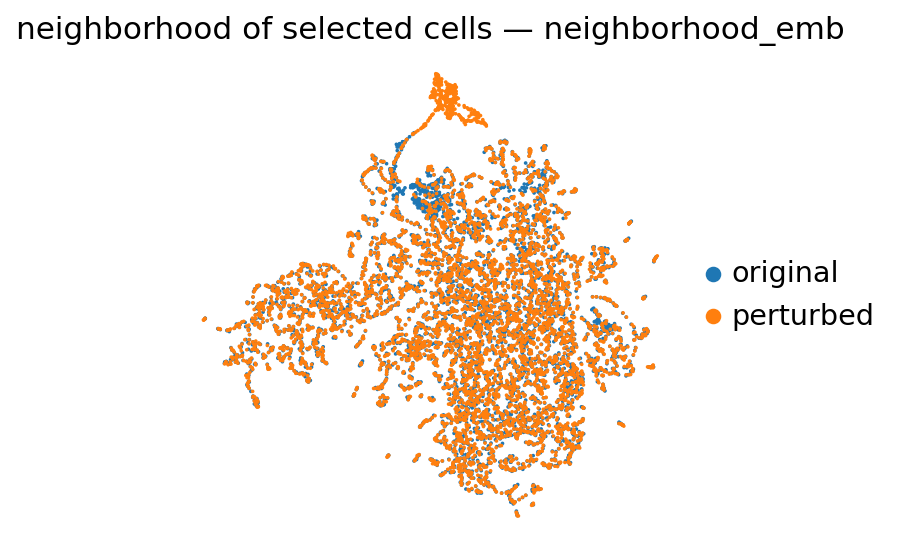

In [16]:
# How far each perturbation moved the embeddings (mean L2 shift vs. the
# unperturbed run), for both the cell and neighborhood representations. Edits on
# a selected subset of cells move the averages less than the whole-panel edits,
# which change every cell.
for emb_key in ["cell_emb", "neighborhood_emb"]:
    base = adata.obsm[emb_key]
    print(emb_key)
    for name, emb in results.items():
        shift = np.linalg.norm(emb[emb_key] - base, axis=1).mean()
        print(f"  {name:34s} mean shift {shift:.3f}")

# Visualize each perturbation in the space it acts on: the cell-target
# fold-change in the cell embedding, the neighborhood-target knockout in the
# neighborhood embedding. Original vs perturbed in a shared UMAP.
for name, emb_key in [("fold-change genes (all cells)", "cell_emb"),
                      ("neighborhood of selected cells", "neighborhood_emb")]:
    joint = sc.AnnData(np.vstack([adata.obsm[emb_key], results[name][emb_key]]))
    joint.obs["state"] = ["original"] * adata.n_obs + ["perturbed"] * adata.n_obs
    sc.pp.neighbors(joint, use_rep="X", n_neighbors=15)
    sc.tl.umap(joint)
    sc.pl.umap(joint, color="state", title=f"{name} — {emb_key}")

## Next steps

- {doc}`perturbation_tutorial` — knock out genes *in silico* and score the effect on each niche.
- {doc}`spatial_mapping_tutorial` — project a per-cell perturbation score back onto the tissue.
- {doc}`../api` and {doc}`../user_guide` — the full function reference and the concepts behind the embeddings.

**Questions or issues?** Please report them on the [TERRA GitHub repository](https://github.com/Lotfollahi-lab/terra/issues).